# Step 1 — Almond units and CIMIS stations

Spec: `CLAUDE.md` §6 Step 1, as amended in `SPEC_CHANGELOG.md`.

**What this step produces**

1. The almond unit layer from DWR / Land IQ Statewide Crop Mapping 2023 final: acreage by
   region, unit count, size distribution.
2. The CIMIS station list: stations inside or within 10 km of almond acreage, with elevation
   and years of record; and how many units have a station within 5, 10 and 20 km.
3. The CDL comparison in both directions: what share of CDL almond area falls inside DWR almond
   fields, and what share of DWR almond area CDL calls almonds.
4. Figure 1.

**Denominator rule (`CLAUDE.md` §9).** Every count below is printed against what it was drawn
from. Nothing is filtered silently: fields under the 5-acre cut and fields outside the three
strata stay in the table, flagged, so the effect of each rule is visible.

**Crop code.** `D12` is class **D — Deciduous Fruits and Nuts**, subclass **12 — Almonds**,
confirmed against DWR's published *Standard Land Use Legend (2022, remote-sensing version)*, not
inferred from the acreage looking right. The same legend gives D13 = Walnuts and D14 = Pistachios,
which is the check that the ordering of the three largest nut classes in this file is not a
coincidence.

In [1]:
import json
import sys
import time

import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from shapely.geometry import Point

import cdl
import cimis
import common as C
import ee_assets
import maps
from dwr_almond import check_region_rule, gdb_path, load_almonds

ee.Initialize(project=C.EE_PROJECT)
C.DERIVED.mkdir(parents=True, exist_ok=True)
C.FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams["mathtext.default"] = "regular"

print("DWR file :", C.DWR_GDB.name)
print("layer    :", C.DWR_LAYER)
print("crop code:", C.ALMOND_CODE, "= class D (Deciduous Fruits and Nuts), subclass 12 (Almonds)")
print("size cut :", C.MIN_ACRES, "acres")
print("CDL      :", C.CDL, "class", C.CDL_ALMOND, "year", C.CDL_YEAR)
print(f"strata   : latitude bands at {C.BOUNDARY_SAC_SJN} N and {C.BOUNDARY_SJN_SJS} N, "
      f"{len(C.STUDY_COUNTIES)} counties")

DWR file : i15_crop_mapping_2023_final.gdb.zip
layer    : i15_Crop_Mapping_2023
crop code: D12 = class D (Deciduous Fruits and Nuts), subclass 12 (Almonds)
size cut : 5.0 acres
CDL      : USDA/NASS/CDL class 75 year 2023
strata   : latitude bands at 38.25 N and 36.82 N, 24 counties


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


## 1a — Which field carries the crop

`CLAUDE.md` §9 forbids inheriting a selector from an earlier project without re-verifying it
against this file's own schema. The tabulation below is that check, and it is the reason the rule
exists: in the 2023 final geodatabase the crop lives in `MAIN_CROP`, while `CROPTYP1`, `CLASS1`
and `SUBCLASS1` — the fields the strawberry study used — are `****` for most of the file.

In [2]:
import collections

import fiona

counts = {k: collections.Counter() for k in ["CLASS1", "CROPTYP1", "MAIN_CROP"]}
acres = {k: collections.Counter() for k in ["CLASS1", "CROPTYP1", "MAIN_CROP"]}
n_total = 0
t0 = time.time()
with fiona.open(gdb_path(), layer=C.DWR_LAYER) as src:
    for f in src:
        p = f["properties"]
        n_total += 1
        a = p["ACRES"] or 0.0
        for k in counts:
            counts[k][p[k]] += 1
            acres[k][p[k]] += a
print(f"{n_total:,} fields scanned in {time.time() - t0:.0f} s\n")

blank = {"CLASS1": "**", "CROPTYP1": "****", "MAIN_CROP": None}
for k in ["CLASS1", "CROPTYP1", "MAIN_CROP"]:
    nb = counts[k][blank[k]]
    print(f"{k:<10} {len(counts[k]):>3} distinct values | unpopulated in {nb:>7,} of "
          f"{n_total:,} fields ({100 * nb / n_total:4.1f}%)")

print(f"\nD12 (Almonds) by selector, out of {n_total:,} fields:")
for k in ["CLASS1", "CROPTYP1", "MAIN_CROP"]:
    key = "D12" if k != "CLASS1" else "D"
    print(f"  {k:<10} == {key!r:<6} : {counts[k][key]:>7,} fields, {acres[k][key]:>12,.0f} acres")
print("\nThe three largest nut classes in MAIN_CROP, against the published legend:")
for code_, name in [("D12", "Almonds"), ("D13", "Walnuts"), ("D14", "Pistachios")]:
    print(f"  {code_} {name:<11} {counts['MAIN_CROP'][code_]:>7,} fields, "
          f"{acres['MAIN_CROP'][code_]:>12,.0f} acres")

446,914 fields scanned in 19 s

CLASS1       9 distinct values | unpopulated in 419,240 of 446,914 fields (93.8%)
CROPTYP1    37 distinct values | unpopulated in 419,240 of 446,914 fields (93.8%)
MAIN_CROP   58 distinct values | unpopulated in       0 of 446,914 fields ( 0.0%)

D12 (Almonds) by selector, out of 446,914 fields:
  CLASS1     == 'D'    :       0 fields,            0 acres
  CROPTYP1   == 'D12'  :     302 fields,        8,411 acres
  MAIN_CROP  == 'D12'  :  45,404 fields,    1,524,133 acres

The three largest nut classes in MAIN_CROP, against the published legend:
  D12 Almonds      45,404 fields,    1,524,133 acres
  D13 Walnuts      18,667 fields,      419,422 acres
  D14 Pistachios   10,984 fields,      602,106 acres


## 1b — The unit layer

Units are DWR 2023 almond fields of at least 5 acres (`CLAUDE.md` §5.1). Smaller fields stay in
the table with `is_unit = 0` so the cut stays auditable.

**Region definition (`CLAUDE.md` §5.1a, amended 2026-09-22).** The county pairs in the original
spec were illustrations of a north/south split, not a definition, and taking them literally left
26.7% of state almond acreage unassigned. The strata are now two latitude boundaries, placed to
fall *between* counties and chosen as the local minima of almond acreage landing on the wrong
side. **Every almond county is assigned; coverage is 100%.**

Each county is assigned **whole**, by the acreage-weighted median latitude of its own almond
fields. Assignment is at county level and never at field level, because federal crop insurance is
administered county by county: a stratum that cannot be written as a county list cannot be mapped
onto the program by the audience for this document. The latitude rule *derives* the list; the
frozen list in `common.py` is what the study uses, and the cell below re-checks one against the
other and raises if they have drifted apart.

Counties whose acreage straddles their boundary are **reported, not forced**. DWR's own published
boundary (`HYDRO_RGN` = "Sacramento River") is kept as a stated sensitivity.

In [3]:
g = load_almonds()
g.to_file(C.DERIVED / "01_almond_fields_dwr2023.gpkg", layer="almond_fields", driver="GPKG",
          engine="fiona")

print(f"DWR {C.ALMOND_CODE} fields statewide : {len(g):>7,}  {g.ACRES.sum():>12,.0f} acres")
small = g[g.is_unit == 0]
print(f"below the {C.MIN_ACRES:.0f}-acre cut       : {len(small):>7,}  {small.ACRES.sum():>12,.0f} "
      f"acres ({100 * small.ACRES.sum() / g.ACRES.sum():.2f}% of acreage)")
u = g[g.is_unit == 1]
print(f"units (>= {C.MIN_ACRES:.0f} acres)         : {len(u):>7,}  {u.ACRES.sum():>12,.0f} acres")

# Re-derive the county -> stratum map from the latitude rule and check the frozen list.
county_table = check_region_rule(g)
print("frozen county list agrees with the latitude rule at "
      f"{C.BOUNDARY_SAC_SJN} N and {C.BOUNDARY_SJN_SJS} N")

study = u[u.study_region != "unassigned"]
n_unassigned = int((u.study_region == "unassigned").sum())
assert n_unassigned == 0, f"{n_unassigned} units fall in no stratum"
print(f"units assigned to a stratum  : {len(study):>7,} of {len(u):,}  "
      f"{study.ACRES.sum():>12,.0f} acres")
print(f"COVERAGE of state almond units: {100 * study.ACRES.sum() / u.ACRES.sum():.2f}%  "
      f"({len(county_table)} counties, none unassigned)")

rows = []
for r in C.REGION_ORDER:
    sr = u[u.study_region == r]
    rows.append({"region": C.REGION_LABELS[r], "counties": len(C.REGION_COUNTIES[r]),
                 "units": len(sr), "acres": round(sr.ACRES.sum()),
                 "mean_ac": round(sr.ACRES.mean(), 1), "median_ac": round(sr.ACRES.median(), 1),
                 "p10_ac": round(sr.ACRES.quantile(0.10), 1),
                 "p90_ac": round(sr.ACRES.quantile(0.90), 1), "max_ac": round(sr.ACRES.max())})
region_table = pd.DataFrame(rows)
print("\n" + region_table.to_string(index=False))

print("\nCOUNTY MEMBERSHIP (CLAUDE.md §6 Step 1). straddle_pct is the share of that county's own "
      "almond\nacreage lying on the far side of its boundary:")
print(county_table.to_string(index=False))

strad = county_table[county_table.straddle_pct > 5]
print(f"\ntotal straddling acreage: {county_table.straddle_acres.sum():,} acres = "
      f"{100 * county_table.straddle_acres.sum() / county_table.acres.sum():.2f}% of state almond units")
print(f"counties straddling by more than 5% of their own acreage: {len(strad)} of {len(county_table)}")
for r in strad.itertuples():
    print(f"   {r.county:<12} {r.stratum:<11} {r.straddle_pct:>5.1f}%  "
          f"({r.straddle_acres:,} of {r.acres:,} acres)")
print("   Sacramento and San Joaquin interlock across the Delta; no latitude separates them")
print("   cleanly. That is the geography, not a defect of the rule.")

nv = county_table[~county_table.central_valley]
print(f"\nalmond counties outside the Central Valley, assigned by the same rule rather than "
      f"special-cased:\n   {len(nv)} counties, {nv.acres.sum():,} acres = "
      f"{100 * nv.acres.sum() / county_table.acres.sum():.2f}% of the assigned total "
      f"({', '.join(nv.county)})")

alt = u[u.HYDRO_RGN == C.SAC_HYDRO_RGN]
sac = u[u.study_region == "sac_valley"]
print(f"\nSENSITIVITY  Sacramento Valley by county list : {len(sac):,} units, "
      f"{sac.ACRES.sum():,.0f} acres")
print(f"             by DWR HYDRO_RGN                 : {len(alt):,} units, {alt.ACRES.sum():,.0f} acres")
print(f"             difference                       : {len(sac) - len(alt):,} units, "
      f"{sac.ACRES.sum() - alt.ACRES.sum():,.0f} acres "
      f"({100 * abs(sac.ACRES.sum() - alt.ACRES.sum()) / sac.ACRES.sum():.1f}% of the region). "
      "The county list is kept: crop insurance is administered by county.")

print("\nSTRATIFICATION SENSITIVITY carried to Step 4 -- each boundary moved by one county:")
for scheme, moves in C.REGION_SCHEMES.items():
    if scheme == "base":
        continue
    col = u[f"region_{scheme}"]
    shifted = u.ACRES[col != u.study_region].sum()
    sizes = {C.REGION_LABELS[r]: f"{u.ACRES[col == r].sum():,.0f}" for r in C.REGION_ORDER}
    print(f"   {scheme:<8} {str(moves):<34} moves {shifted:>9,.0f} acres  -> {sizes}")

DWR D12 fields statewide :  45,404     1,524,133 acres
below the 5-acre cut       :   6,302        14,872 acres (0.98% of acreage)
units (>= 5 acres)         :  39,102     1,509,261 acres
frozen county list agrees with the latitude rule at 38.25 N and 36.82 N
units assigned to a stratum  :  39,102 of 39,102     1,509,261 acres
COVERAGE of state almond units: 100.00%  (24 counties, none unassigned)

           region  counties  units  acres  mean_ac  median_ac  p10_ac  p90_ac  max_ac
Sacramento Valley        11   7366 292322     39.7       30.5     8.9    77.6     446
San Joaquin north         7  18694 621091     33.2       22.2     7.9    74.0     554
San Joaquin south         6  13042 595848     45.7       37.2    11.9    79.2     355

COUNTY MEMBERSHIP (CLAUDE.md §6 Step 1). straddle_pct is the share of that county's own almond
acreage lying on the far side of its boundary:
         county    stratum  acres  units  median_lat  straddle_acres  straddle_pct  central_valley
         Col

## 1c — Size distribution, and whether a 1 km pixel can see an orchard

A 1 km LST pixel covers 100 ha = **247 acres**. The relevant question for Step 4 is not whether
a single DWR polygon fills one — almost none do — but whether almond acreage sits in contiguous
blocks large enough to fill one, since adjacent fields are also almonds. Both are reported.

Blocks are built by buffering units out 30 m, dissolving, and buffering back in, so that fields
separated only by a farm road merge. That fills interior gaps, which inflates block acreage
slightly relative to the summed field acreage; the inflation is printed.

In [4]:
print(f"unit size, all strata (n = {len(study):,} units, {study.ACRES.sum():,.0f} acres):")
print(study.ACRES.describe(percentiles=[.1, .25, .5, .75, .9, .99]).round(1).to_string())

bins = [5, 10, 20, 40, 80, 160, 1e4]
labels = ["5-10", "10-20", "20-40", "40-80", "80-160", "160+"]
cut = pd.cut(study.ACRES, bins=bins, labels=labels, right=False)
size_table = pd.DataFrame({
    "units": cut.value_counts().reindex(labels),
    "acres": study.groupby(cut, observed=False).ACRES.sum().reindex(labels).round(0)})
size_table["unit_%"] = (100 * size_table.units / size_table.units.sum()).round(1)
size_table["acre_%"] = (100 * size_table.acres / size_table.acres.sum()).round(1)
print("\n" + size_table.to_string())

metric = study.to_crs(C.METRIC_CRS)
t0 = time.time()
blocks = gpd.GeoSeries([metric.buffer(30).union_all()], crs=C.METRIC_CRS).explode(index_parts=False)
blocks = blocks.buffer(-30)
blocks = blocks[~blocks.is_empty]
block_ac = blocks.area / cdl.ACRE_M2
print(f"\ncontiguous almond blocks (30 m merge): {len(blocks):,} blocks from {len(study):,} units, "
      f"{time.time() - t0:.0f} s")
print(f"  block acreage {block_ac.sum():,.0f} vs summed unit acreage {study.ACRES.sum():,.0f} "
      f"(+{100 * (block_ac.sum() / study.ACRES.sum() - 1):.1f}% from filled interior gaps)")
print(f"  block size acres: median {block_ac.median():.0f}, 90th {block_ac.quantile(.9):.0f}, "
      f"max {block_ac.max():,.0f}")
print(f"\n  single units >= 247 acres (one whole 1 km pixel): {(study.ACRES >= 247).sum():,} of "
      f"{len(study):,} ({100 * (study.ACRES >= 247).mean():.1f}%), "
      f"{100 * study.ACRES[study.ACRES >= 247].sum() / study.ACRES.sum():.1f}% of acreage")
for thr, lab in [(62, "62 ac  = quarter of a 1 km pixel"), (247, "247 ac = one 1 km pixel"),
                 (988, "988 ac = a 2x2 km block")]:
    m = block_ac >= thr
    print(f"  blocks >= {lab:<34}: {m.sum():>5,} blocks, {block_ac[m].sum():>9,.0f} acres "
          f"({100 * block_ac[m].sum() / block_ac.sum():4.1f}% of block acreage)")

unit size, all strata (n = 39,102 units, 1,509,261 acres):
count    39102.0
mean        38.6
std         34.7
min          5.0
10%          8.7
25%         15.6
50%         29.6
75%         49.7
90%         77.5
99%        158.5
max        554.2

        units     acres  unit_%  acre_%
ACRES                                  
5-10     5508   42045.0    14.1     2.8
10-20    9370  145789.0    24.0     9.7
20-40   12044  379769.0    30.8    25.2
40-80    9048  553237.0    23.1    36.7
80-160   2784  313500.0     7.1    20.8
160+      348   74920.0     0.9     5.0



contiguous almond blocks (30 m merge): 4,471 blocks from 39,102 units, 13 s
  block acreage 1,565,058 vs summed unit acreage 1,509,261 (+3.7% from filled interior gaps)
  block size acres: median 64, 90th 509, max 69,102

  single units >= 247 acres (one whole 1 km pixel): 73 of 39,102 (0.2%), 1.5% of acreage
  blocks >= 62 ac  = quarter of a 1 km pixel  : 2,259 blocks, 1,505,971 acres (96.2% of block acreage)
  blocks >= 247 ac = one 1 km pixel           :   860 blocks, 1,329,443 acres (84.9% of block acreage)
  blocks >= 988 ac = a 2x2 km block           :   227 blocks, 1,027,993 acres (65.7% of block acreage)


## 1d — CIMIS stations

Station metadata comes from `GetAllStations`. The legacy Web API (key as an `appKey` query
parameter) was retired on 31 July 2026; the current endpoint sits behind Azure API Management and
takes the key as the `Ocp-Apim-Subscription-Key` header. The key is read from the gitignored
`.env`, never printed, never placed in a URL.

**Elevation units are checked, not assumed.** The API does not state a unit. The check compares
every station's reported elevation against SRTM at the station's own coordinates.

**Years of record are nominal.** `ConnectDate` and `DisconnectDate` describe when the station
existed, not which nights actually reported. Active stations carry the placeholder disconnect
date 31 December 2050. Real per-night availability is established in Step 2, where the pull
reports its own denominator.

In [5]:
stations = pd.DataFrame(cimis.fetch_stations())
stations["lat"] = stations.HmsLatitude.map(cimis.decimal_from_hms)
stations["lon"] = stations.HmsLongitude.map(cimis.decimal_from_hms)
stations["elev_ft"] = pd.to_numeric(stations.Elevation, errors="coerce")
stations["connect"] = pd.to_datetime(stations.ConnectDate, format="%m/%d/%Y", errors="coerce")
stations["disconnect"] = pd.to_datetime(stations.DisconnectDate, format="%m/%d/%Y", errors="coerce")
print(f"stations returned            : {len(stations):,}")
print(f"  missing coordinates        : {stations.lat.isna().sum() + stations.lon.isna().sum()}")
print(f"  unparsed ConnectDate       : {stations.connect.isna().sum()}")
print(f"  unparsed DisconnectDate    : {stations.disconnect.isna().sum()}")
print(f"  IsActive                   : {stations.IsActive.value_counts().to_dict()}")

# --- units check on Elevation (CLAUDE.md §9) ---------------------------------------------
pts = ee.FeatureCollection([ee.Feature(ee.Geometry.Point([float(r.lon), float(r.lat)]),
                                       {"n": str(r.StationNbr)})
                            for r in stations.dropna(subset=["lat", "lon"]).itertuples()])
dem_vals = ee.Image("USGS/SRTMGL1_003").rename("dem_m").reduceRegions(
    pts, ee.Reducer.first(), 30).getInfo()["features"]
dem_df = pd.DataFrame([{"StationNbr": f["properties"]["n"],
                        "dem_m": f["properties"].get("first")} for f in dem_vals])
chk = stations.merge(dem_df, on="StationNbr").dropna(subset=["dem_m", "elev_ft"])
chk = chk[chk.elev_ft > 0]
r_ft = (chk.elev_ft / (chk.dem_m / 0.3048)).median()
r_m = (chk.elev_ft / chk.dem_m).median()
print(f"\nElevation units check, {len(chk)} of {len(stations)} stations compared against SRTM:")
print(f"  median ratio CIMIS / (SRTM in feet)  = {r_ft:.3f}   <- 1.0 means the field is feet")
print(f"  median ratio CIMIS / (SRTM in metres)= {r_m:.3f}")
print(f"  median absolute difference, as feet  = {(chk.elev_ft - chk.dem_m / 0.3048).abs().median():.0f} ft")
assert 0.9 < r_ft < 1.1, "CIMIS Elevation is not in feet; re-check before using it"
stations["elev_m"] = stations.elev_ft * 0.3048
print("  -> CIMIS Elevation is FEET; elev_m added.")

stations returned            : 276
  missing coordinates        : 0
  unparsed ConnectDate       : 0
  unparsed DisconnectDate    : 0
  IsActive                   : {'True': 147, 'False': 129}



Elevation units check, 258 of 276 stations compared against SRTM:
  median ratio CIMIS / (SRTM in feet)  = 0.999   <- 1.0 means the field is feet
  median ratio CIMIS / (SRTM in metres)= 3.278
  median absolute difference, as feet  = 7 ft
  -> CIMIS Elevation is FEET; elev_m added.


In [6]:
sg = gpd.GeoDataFrame(stations.drop(columns=["ZipCodes"]),
                      geometry=[Point(x, y) for x, y in zip(stations.lon, stations.lat)],
                      crs="EPSG:4326").to_crs(C.METRIC_CRS)
almond_union = metric.geometry.union_all()
sg["dist_to_almond_km"] = (sg.distance(almond_union) / 1000).round(2)

# operating at any point in the study window, from the nominal dates
OPEN, CLOSE = pd.Timestamp("2015-02-01"), pd.Timestamp("2025-03-31")
sg["in_window"] = (sg.connect <= CLOSE) & (sg.disconnect >= OPEN)

near = sg[sg.dist_to_almond_km <= 10].copy()
print(f"stations within 10 km of study-region almond acreage: {len(near)} of {len(sg)}")
print(f"  of those, nominally operating 2015-2025 : {int(near.in_window.sum())}")
print(f"  of those, flagged active today          : {int((near.IsActive == 'True').sum())}")
print(f"  elevation (m): median {near.elev_m.median():.0f}, range {near.elev_m.min():.0f}"
      f"-{near.elev_m.max():.0f}")
print(f"\nby region office: {near.RegionalOffice.value_counts().to_dict()}")
print("\nStations within 10 km, nominally operating in the study window:")
cols = ["StationNbr", "Name", "County", "elev_ft", "elev_m", "dist_to_almond_km",
        "ConnectDate", "DisconnectDate", "IsActive"]
show = near[near.in_window].sort_values("dist_to_almond_km")[cols].copy()
show["elev_m"] = show.elev_m.round(0)
print(show.to_string(index=False))

stations within 10 km of study-region almond acreage: 82 of 276
  of those, nominally operating 2015-2025 : 55
  of those, flagged active today          : 39
  elevation (m): median 59, range -4-270

by region office: {'South Central Region Office': 43, 'North Central Region Office': 25, 'Northern Region Office': 10, 'Southern Region Office': 4}

Stations within 10 km, nominally operating in the study window:
StationNbr                   Name          County  elev_ft  elev_m  dist_to_almond_km ConnectDate DisconnectDate IsActive
       161              Patterson      Stanislaus      183    56.0               0.00   8/23/1999     10/12/2017    False
       121                  Dixon          Solano       37    11.0               0.00   9/20/1994       7/6/2021    False
       188              Madera II          Madera      242    74.0               0.00   3/27/2013      6/23/2018    False
       138                 Famoso            Kern      415   126.0               0.09    4/9/1997  

In [7]:
cent = gpd.GeoDataFrame(study[["UniqueID", "ACRES", "study_region"]].copy(),
                        geometry=metric.geometry.centroid, crs=C.METRIC_CRS)
pools = [("all 276 stations", sg),
         ("nominally operating 2015-2025", sg[sg.in_window]),
         ("flagged active today", sg[sg.IsActive == "True"])]
dist_rows = []
for label, pool in pools:
    j = gpd.sjoin_nearest(cent, pool[["StationNbr", "geometry"]], how="left",
                          distance_col="d").drop_duplicates(subset="UniqueID")
    d = j.d.values / 1000.0
    print(f"\n{label} (n = {len(pool)}):  denominator {len(d):,} units, {j.ACRES.sum():,.0f} acres")
    for km in (5, 10, 20):
        m = d <= km
        print(f"   within {km:>2} km: {m.sum():>6,} units ({100 * m.mean():4.1f}%), "
              f"{j.ACRES[m].sum():>9,.0f} acres ({100 * j.ACRES[m].sum() / j.ACRES.sum():4.1f}%)")
        dist_rows.append({"pool": label, "km": km, "units": int(m.sum()),
                          "unit_pct": round(100 * m.mean(), 1),
                          "acres": round(j.ACRES[m].sum()),
                          "acre_pct": round(100 * j.ACRES[m].sum() / j.ACRES.sum(), 1)})
    print(f"   nearest station: median {np.median(d):.1f} km, 90th {np.percentile(d, 90):.1f} km, "
          f"max {d.max():.1f} km")
    print("   median km by region:",
          j.assign(d_km=d).groupby("study_region").d_km.median().round(1).to_dict())
    if label == "nominally operating 2015-2025":
        study_dist = j.assign(nearest_station_km=d.round(2))
dist_table = pd.DataFrame(dist_rows)


all 276 stations (n = 276):  denominator 39,102 units, 1,509,261 acres
   within  5 km:  4,526 units (11.6%),   174,353 acres (11.6%)
   within 10 km: 14,426 units (36.9%),   565,126 acres (37.4%)
   within 20 km: 34,388 units (87.9%), 1,334,602 acres (88.4%)
   nearest station: median 12.3 km, 90th 20.7 km, max 41.6 km
   median km by region: {'sac_valley': 11.1, 'sj_north': 12.4, 'sj_south': 12.8}

nominally operating 2015-2025 (n = 179):  denominator 39,102 units, 1,509,261 acres
   within  5 km:  3,125 units ( 8.0%),   120,002 acres ( 8.0%)
   within 10 km: 11,084 units (28.3%),   425,633 acres (28.2%)
   within 20 km: 29,204 units (74.7%), 1,123,926 acres (74.5%)
   nearest station: median 14.4 km, 90th 26.5 km, max 55.5 km
   median km by region: {'sac_valley': 18.5, 'sj_north': 12.7, 'sj_south': 16.1}



flagged active today (n = 147):  denominator 39,102 units, 1,509,261 acres
   within  5 km:  1,709 units ( 4.4%),    64,347 acres ( 4.3%)
   within 10 km:  7,589 units (19.4%),   280,847 acres (18.6%)
   within 20 km: 23,230 units (59.4%),   883,871 acres (58.6%)
   nearest station: median 17.3 km, 90th 33.7 km, max 55.8 km
   median km by region: {'sac_valley': 24.8, 'sj_north': 16.2, 'sj_south': 16.9}


## 1e — The CDL comparison

CDL is a comparison layer only; it never defines a unit (`CLAUDE.md` §5.1). Both directions are
computed on CDL's own 30 m grid, so the DWR side is rasterised area rather than polygon `ACRES`.

The denominator for direction 2 is CDL almond area inside the study counties — now all 24
counties with almond acreage, so the two sides cover the same ground and the comparison is
statewide rather than a 73% subset.

In [8]:
asset = ee_assets.upload(g)
fc = ee.FeatureCollection(asset)
n_asset = fc.size().getInfo()
n_units_asset = fc.filter(ee.Filter.eq("is_unit", 1)).size().getInfo()
print(f"asset {asset}")
print(f"  features {n_asset:,} (DWR gave {len(g):,}) | is_unit=1 {n_units_asset:,} "
      f"(local {int(g.is_unit.sum()):,})")
assert n_asset == len(g) and n_units_asset == int(g.is_unit.sum()), "asset does not match DWR"

rows = []
for r in ["sac_valley", "sj_north", "sj_south"]:
    rows.append(cdl.dwr_overlap(asset, r))
cdl_table = pd.DataFrame(rows)
cdl_table["cdl_almond_pct_of_dwr"] = (100 * cdl_table.cdl_almond_in_dwr_acres
                                      / cdl_table.dwr_acres_30m).round(1)
cdl_table[["dwr_acres_30m", "cdl_almond_in_dwr_acres"]] = \
    cdl_table[["dwr_acres_30m", "cdl_almond_in_dwr_acres"]].round(0)
print("\n" + cdl_table.to_string(index=False))

in_dwr = cdl_table.cdl_almond_in_dwr_acres.sum()
dwr_30m = cdl_table.dwr_acres_30m.sum()
county_total = cdl.cdl_almond_in_counties(C.STUDY_COUNTIES)
statewide_cdl = cdl.cdl_almond_statewide()
small_in_counties = g[(g.is_unit == 0) & (g.COUNTY.isin(C.STUDY_COUNTIES))].ACRES.sum()
print(f"\nDIRECTION 1  of {dwr_30m:,.0f} acres of DWR almond units, CDL calls "
      f"{in_dwr:,.0f} almonds = {100 * in_dwr / dwr_30m:.1f}%")
print(f"DIRECTION 2  of {county_total:,.0f} acres CDL calls almonds in the "
      f"{len(C.STUDY_COUNTIES)} almond counties, {in_dwr:,.0f} fall inside DWR almond units "
      f"= {100 * in_dwr / county_total:.1f}%")
print(f"             those counties hold {100 * county_total / statewide_cdl:.1f}% of the "
      f"{statewide_cdl:,.0f} acres CDL calls almonds statewide")
print(f"             CDL almond acreage with no DWR almond unit under it: "
      f"{county_total - in_dwr:,.0f} acres ({100 * (1 - in_dwr / county_total):.1f}%)")
print(f"             of which at most {small_in_counties:,.0f} acres "
      f"({100 * small_in_counties / county_total:.1f}%) is DWR almond below the 5-acre cut")
print(f"\nFor scale: CDL 2023 calls {county_total:,.0f} acres almonds in these counties against "
      f"{dwr_30m:,.0f} from DWR, {100 * county_total / dwr_30m - 100:+.0f}% -- a difference of "
      f"{county_total - dwr_30m:,.0f} acres. Neither map is ground truth; the unit layer carries "
      "that\nuncertainty into every temperature result that follows.")

  12 chunk export(s) started, 12 chunks total


  chunk 00: COMPLETED at 20 s
  chunk 01: COMPLETED at 20 s


  chunk 02: COMPLETED at 88 s


  chunk 03: COMPLETED at 155 s


  chunk 04: COMPLETED at 220 s


...

  merged in 122 s


projects/cropczyk/assets/almond/dwr2023_almond_fields: 45404 features (matches the 45404 fields read from DWR)


asset projects/cropczyk/assets/almond/dwr2023_almond_fields
  features 45,404 (DWR gave 45,404) | is_unit=1 39,102 (local 39,102)



    region  n_units  dwr_acres_30m  cdl_almond_in_dwr_acres  cdl_almond_pct_of_dwr
sac_valley     7366       292244.0                 230532.0                   78.9
  sj_north    18694       620912.0                 536374.0                   86.4
  sj_south    13042       595707.0                 517721.0                   86.9



DIRECTION 1  of 1,508,863 acres of DWR almond units, CDL calls 1,284,627 almonds = 85.1%
DIRECTION 2  of 1,849,423 acres CDL calls almonds in the 24 almond counties, 1,284,627 fall inside DWR almond units = 69.5%
             those counties hold 98.7% of the 1,873,606 acres CDL calls almonds statewide
             CDL almond acreage with no DWR almond unit under it: 564,796 acres (30.5%)
             of which at most 14,868 acres (0.8%) is DWR almond below the 5-acre cut

For scale: CDL 2023 calls 1,849,423 acres almonds in these counties against 1,508,863 from DWR, +23% -- a difference of 340,560 acres. Neither map is ground truth; the unit layer carries that
uncertainty into every temperature result that follows.


## 1f — Figure 1 and the derived tables

Figure 1: 39,102 units in three strata (1,509,261 acres), 6,302 almond fields below the 5-acre cut, 276 stations (82 within 10 km)
saved figures/fig01_units_stations.png


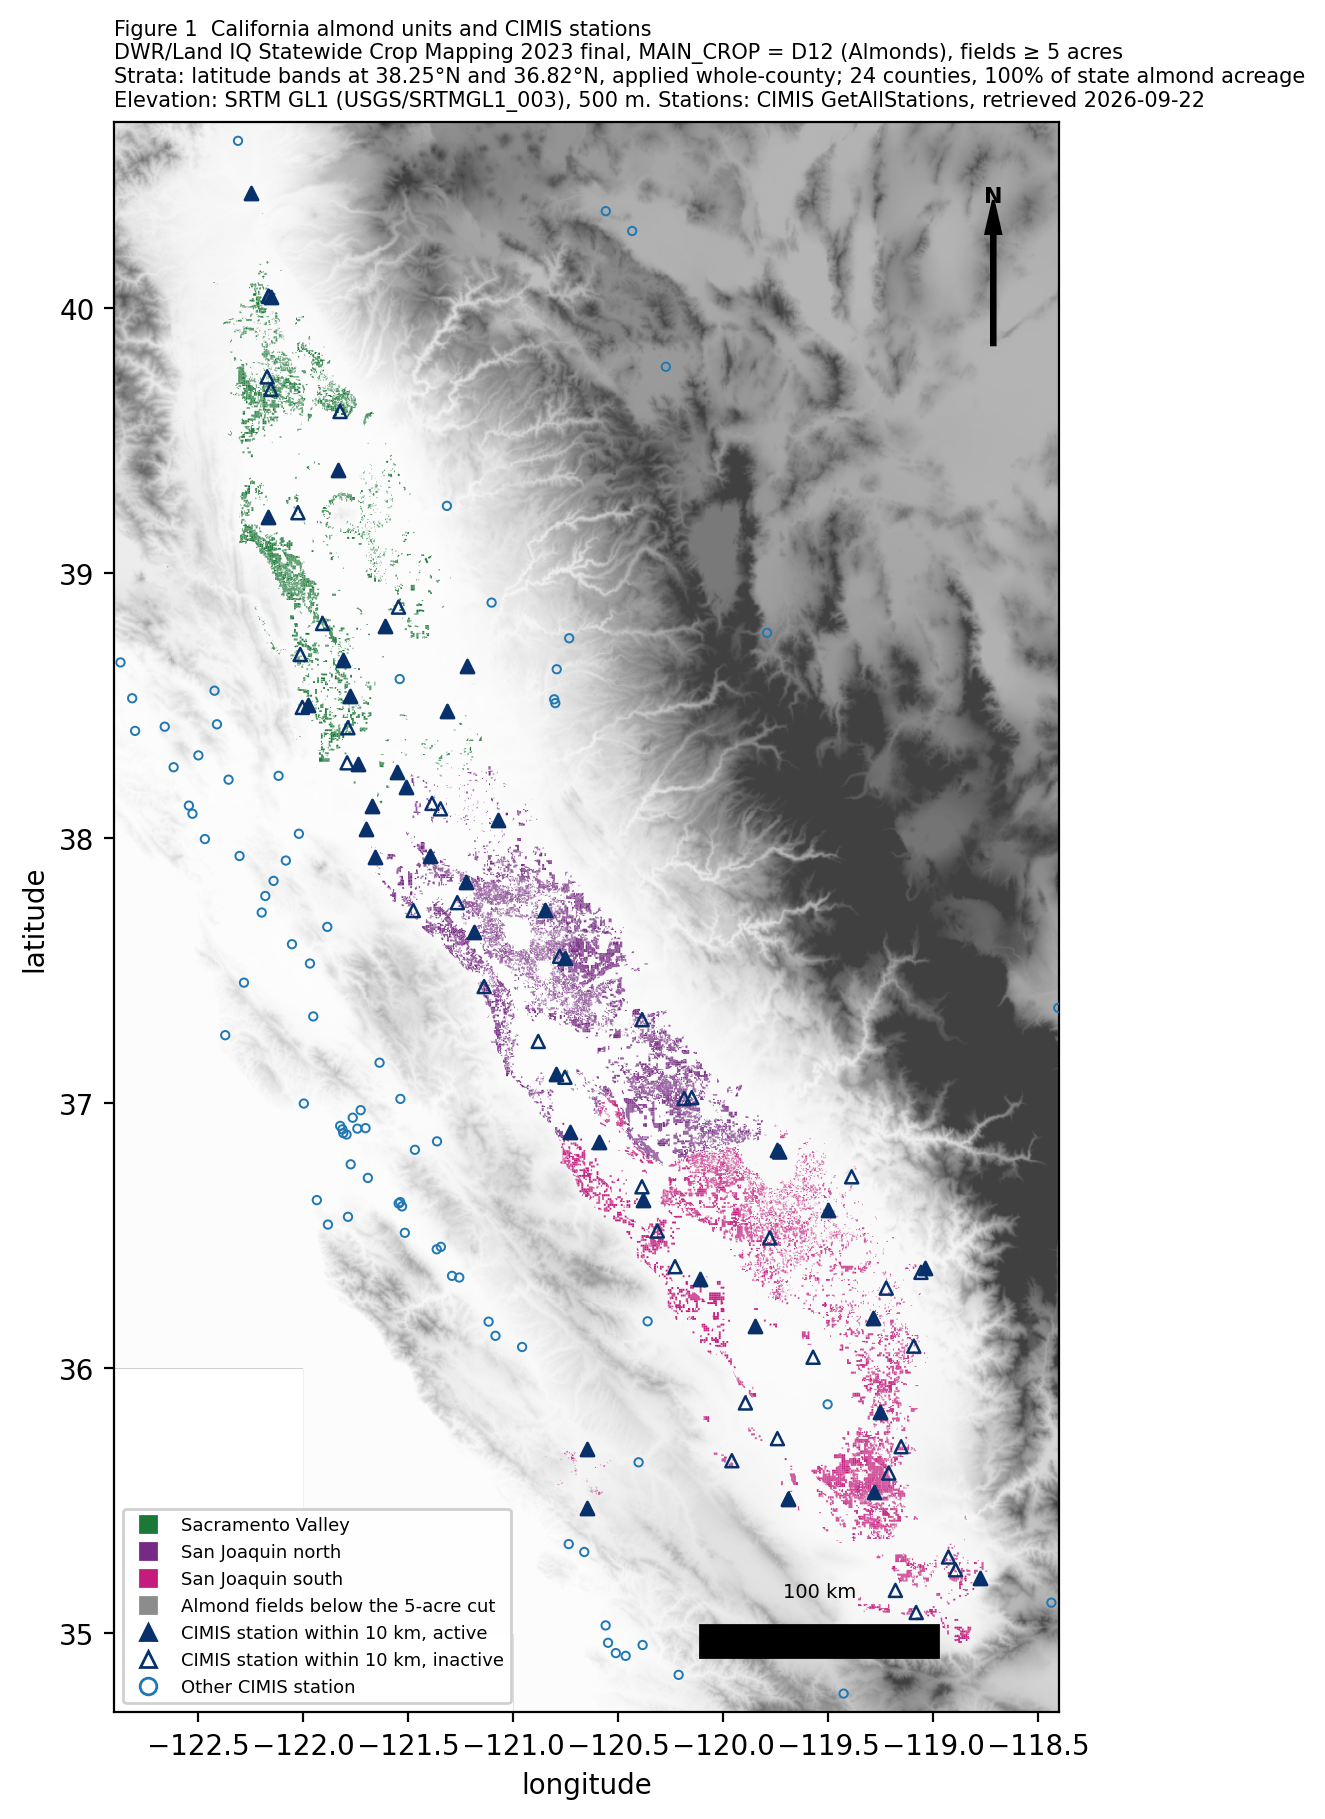

In [9]:
gl = g.to_crs("EPSG:4326")
ul = gl[gl.is_unit == 1]
other = gl[gl.is_unit == 0]
sl = sg.to_crs("EPSG:4326")
nearl = sl[sl.dist_to_almond_km <= 10]
BBOX = (-122.9, 34.7, -118.4, 40.7)
arr, ext = maps.read_tif(maps.dem_tif(C.DERIVED / "01_srtm_500m.tif", BBOX, 500))
arr = np.where(arr < -100, np.nan, arr)

fig, ax = plt.subplots(figsize=(7.2, 9.2), dpi=200)
ax.imshow(arr, extent=ext, origin="upper", cmap="Greys", vmin=-50, vmax=2500, alpha=0.75, zorder=0)
other.plot(ax=ax, color="0.55", linewidth=0, zorder=2)
for r, colour in maps.REGION_COLORS.items():
    ul[ul.study_region == r].plot(ax=ax, color=colour, linewidth=0, zorder=3)
sl[sl.dist_to_almond_km > 10].plot(ax=ax, color="none", edgecolor="#1f78b4", marker="o",
                                   markersize=9, linewidth=0.7, zorder=4)
nearl[nearl.IsActive == "True"].plot(ax=ax, color="#08306b", marker="^", markersize=22, zorder=5)
nearl[nearl.IsActive != "True"].plot(ax=ax, color="none", edgecolor="#08306b", marker="^",
                                     markersize=22, linewidth=0.9, zorder=5)
ax.set_xlim(BBOX[0], BBOX[2])
ax.set_ylim(BBOX[1], BBOX[3])
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
maps.add_scale_bar(ax, 100, x=0.62, y=0.035, lat=37.5)
maps.add_north_arrow(ax)
handles = [Line2D([], [], marker="s", ls="", color=c, label=C.REGION_LABELS[r])
           for r, c in maps.REGION_COLORS.items()]
handles += [
    Line2D([], [], marker="s", ls="", color="0.55",
           label="Almond fields below the 5-acre cut"),
    Line2D([], [], marker="^", ls="", color="#08306b", label="CIMIS station within 10 km, active"),
    Line2D([], [], marker="^", ls="", mfc="none", mec="#08306b", color="none",
           label="CIMIS station within 10 km, inactive"),
    Line2D([], [], marker="o", ls="", mfc="none", mec="#1f78b4", color="none",
           label="Other CIMIS station")]
ax.legend(handles=handles, loc="lower left", fontsize=6.5, framealpha=0.92)
ax.set_title("Figure 1  California almond units and CIMIS stations\n"
             "DWR/Land IQ Statewide Crop Mapping 2023 final, MAIN_CROP = D12 (Almonds), "
             "fields \u2265 5 acres\n"
             f"Strata: latitude bands at {C.BOUNDARY_SAC_SJN}\u00b0N and "
             f"{C.BOUNDARY_SJN_SJS}\u00b0N, applied whole-county; "
             f"{len(C.STUDY_COUNTIES)} counties, 100% of state almond acreage\n"
             "Elevation: SRTM GL1 (USGS/SRTMGL1_003), 500 m. "
             "Stations: CIMIS GetAllStations, retrieved 2026-09-22",
             fontsize=7.5, loc="left")
fig.tight_layout()
fig.savefig(C.FIGURES / "fig01_units_stations.png", dpi=200, bbox_inches="tight")
print(f"Figure 1: {len(ul):,} units in three strata ({ul.ACRES.sum():,.0f} acres), "
      f"{len(other):,} almond fields below the 5-acre cut, {len(sl):,} stations "
      f"({len(nearl)} within 10 km)")
print("saved figures/fig01_units_stations.png")

In [10]:
units_out = (study.drop(columns="geometry")
             .merge(study_dist[["UniqueID", "nearest_station_km"]], on="UniqueID", how="left"))
units_out.to_csv(C.DERIVED / "01_almond_units.csv", index=False)
sg.drop(columns="geometry").to_csv(C.DERIVED / "01_cimis_stations.csv", index=False)
region_table.to_csv(C.DERIVED / "01_region_table.csv", index=False)
county_table.to_csv(C.DERIVED / "01_county_membership.csv", index=False)
size_table.to_csv(C.DERIVED / "01_size_table.csv")
dist_table.to_csv(C.DERIVED / "01_station_distance_table.csv", index=False)
cdl_table.to_csv(C.DERIVED / "01_cdl_comparison.csv", index=False)

print("=" * 78)
print("STEP 1 CHECKPOINT SUMMARY -- every figure with its denominator")
print("=" * 78)
print(f"DWR 2023 fields scanned                 {n_total:>9,}")
print(f"  MAIN_CROP == D12 (Almonds)            {len(g):>9,}   {g.ACRES.sum():>11,.0f} acres")
print(f"  of those, >= 5 acres  -> units        {len(u):>9,}   {u.ACRES.sum():>11,.0f} acres")
print(f"  of those, assigned to a stratum       {len(study):>9,}   {study.ACRES.sum():>11,.0f} acres"
      f"   ({100 * study.ACRES.sum() / u.ACRES.sum():.2f}% coverage)")
print(f"  in the Earth Engine asset             {n_asset:>9,}   (units {n_units_asset:,})")
print(f"CIMIS stations returned                 {len(sg):>9,}")
print(f"  within 10 km of study almond acreage  {len(near):>9,}")
print(f"  of those, nominally operating 15-25   {int(near.in_window.sum()):>9,}")
n20 = int(dist_table[(dist_table["pool"] == "nominally operating 2015-2025")
                     & (dist_table.km == 20)].units.iloc[0])
print(f"units with a station within 20 km       {n20:>9,}   of {len(study):,}")
print(f"CDL almond inside DWR units             {in_dwr:>9,.0f} acres")
print(f"  as a share of DWR unit area           {100 * in_dwr / dwr_30m:>9.1f}%")
print(f"  as a share of CDL almond in counties  {100 * in_dwr / county_total:>9.1f}%")
print("\nwrote data/derived/: 01_almond_units.csv, 01_cimis_stations.csv, 01_region_table.csv,")
print("      01_county_membership.csv,")
print("      01_size_table.csv, 01_station_distance_table.csv, 01_cdl_comparison.csv")
print("      01_almond_fields_dwr2023.gpkg; figures/fig01_units_stations.png")

STEP 1 CHECKPOINT SUMMARY -- every figure with its denominator
DWR 2023 fields scanned                   446,914
  MAIN_CROP == D12 (Almonds)               45,404     1,524,133 acres
  of those, >= 5 acres  -> units           39,102     1,509,261 acres
  of those, assigned to a stratum          39,102     1,509,261 acres   (100.00% coverage)
  in the Earth Engine asset                45,404   (units 39,102)
CIMIS stations returned                       276
  within 10 km of study almond acreage         82
  of those, nominally operating 15-25          55
units with a station within 20 km          29,204   of 39,102
CDL almond inside DWR units             1,284,627 acres
  as a share of DWR unit area                85.1%
  as a share of CDL almond in counties       69.5%

wrote data/derived/: 01_almond_units.csv, 01_cimis_stations.csv, 01_region_table.csv,
      01_county_membership.csv,
      01_size_table.csv, 01_station_distance_table.csv, 01_cdl_comparison.csv
      01_almond_fields